# Array Print

`arrayprint` takes a `.csv` containing a MITOMI-assayable library in a tabular format
and returns a Scienion-compatible `.fld` file and a `.csv` record of the array layout.

In [1]:
from string import ascii_uppercase
import itertools
import glob

import matplotlib.pyplot as plt
import pandas as pd

import arrayprint

pd.options.display.max_rows = 15
pd.options.display.max_columns = 15

# Create print plates

Create an iterable of 384-well print plate dataframes,
each with rownames = A, B, C, ..., P and colnames 1, 2, 3, ..., 24.

The values should be the name of the oligo in that well,
with `NaN`'s for empty wells,
`wash` for a 70% EtOH wash solution to keep the nozzle clean over a long print,
and `buf` for the 1X print buffer used for spotting on empty cells

In [2]:
print_plate = pd.DataFrame(
    columns=range(1, 25), index=list(ascii_uppercase[:16]), dtype="str"
)

# Oligo dilutions
for oligo, column in itertools.chain(
    zip(range(23, 34), range(1, 23, 2), strict=True),
    zip(range(34, 45), range(2, 24, 2), strict=True),
):
    for dilution, row in enumerate(ascii_uppercase[0:16:2], start=1):
        print_plate.loc[row, column] = f"{oligo}-{dilution}"

# EtOH wash after every concentration
for row in ascii_uppercase[0:16:2]:
    print_plate.loc[row, 24] = arrayprint.WASH

# 1X print buffer for spotting on empty rows
print_plate.loc["P", 24] = arrayprint.BUF

print_plates = [print_plate]
print_plate

,1,2,3,4,5,6,7,...,18,19,20,21,22,23,24
A,23-1,34-1,24-1,35-1,25-1,36-1,26-1,...,42-1,32-1,43-1,33-1,44-1,NaN,WASH
B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C,23-2,34-2,24-2,35-2,25-2,36-2,26-2,...,42-2,32-2,43-2,33-2,44-2,NaN,WASH
D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E,23-3,34-3,24-3,35-3,25-3,36-3,26-3,...,42-3,32-3,43-3,33-3,44-3,NaN,WASH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
M,23-7,34-7,24-7,35-7,25-7,36-7,26-7,...,42-7,32-7,43-7,33-7,44-7,NaN,WASH
N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
O,23-8,34-8,24-8,35-8,25-8,36-8,26-8,...,42-8,32-8,43-8,33-8,44-8,NaN,WASH


# Configure blocks

If you want to spot different oligos in different blocks
(or, alternatively, ensure that oligos are spotted in multiple blocks evenly),
create an iterable of iterables.

The outer level should have as many elements as there are blocks on the device.

The inner level corresponds to which oligos should be spotted in that block.

This is *not* required, and only included as an example.

In [3]:
block_info = [[]]

for oligo in range(23, 45):
    for dilution in range(1, 9):
        block_info[0].append(f"{oligo}-{dilution}")

block_info

[['23-1',
  '23-2',
  '23-3',
  '23-4',
  '23-5',
  '23-6',
  '23-7',
  '23-8',
  '24-1',
  '24-2',
  '24-3',
  '24-4',
  '24-5',
  '24-6',
  '24-7',
  '24-8',
  '25-1',
  '25-2',
  '25-3',
  '25-4',
  '25-5',
  '25-6',
  '25-7',
  '25-8',
  '26-1',
  '26-2',
  '26-3',
  '26-4',
  '26-5',
  '26-6',
  '26-7',
  '26-8',
  '27-1',
  '27-2',
  '27-3',
  '27-4',
  '27-5',
  '27-6',
  '27-7',
  '27-8',
  '28-1',
  '28-2',
  '28-3',
  '28-4',
  '28-5',
  '28-6',
  '28-7',
  '28-8',
  '29-1',
  '29-2',
  '29-3',
  '29-4',
  '29-5',
  '29-6',
  '29-7',
  '29-8',
  '30-1',
  '30-2',
  '30-3',
  '30-4',
  '30-5',
  '30-6',
  '30-7',
  '30-8',
  '31-1',
  '31-2',
  '31-3',
  '31-4',
  '31-5',
  '31-6',
  '31-7',
  '31-8',
  '32-1',
  '32-2',
  '32-3',
  '32-4',
  '32-5',
  '32-6',
  '32-7',
  '32-8',
  '33-1',
  '33-2',
  '33-3',
  '33-4',
  '33-5',
  '33-6',
  '33-7',
  '33-8',
  '34-1',
  '34-2',
  '34-3',
  '34-4',
  '34-5',
  '34-6',
  '34-7',
  '34-8',
  '35-1',
  '35-2',
  '35-3',
  '35-4',


# Project Configuration
Set all project parameters, print settings, and file paths

In [4]:
project = "MyProject"

rows = 56
columns = 32
skip_rows = True
n_blocks = 1
device = "PS1.8K"

print(
    f"{rows * columns} chambers with {n_blocks} block{'s' if n_blocks > 1 else ''},"
    f" {int(rows * columns / n_blocks)} chambers per block"
)

1792 chambers with 1 block, 1792 chambers per block


# Generate print array

Generate print array, keeping the number of replicates roughly constant per variant.

In [5]:
print_array = arrayprint.generate_print_array(
    print_plates=print_plates,
    rows=rows,
    columns=columns,
    skip_rows=skip_rows,
    block_info=block_info,
    empty_buf_well="1P24",
    wash_array_loc=(1, 2),
)

print_array

array([['1G17', '1P24,1A24,1C24,1E24,1G24,1I24,1K24,1M24,1O24', '1M21',
        ..., '1G16', '1O21', '1O13'],
       ['1P24', '1P24', '1P24', ..., '1P24', '1P24', '1P24'],
       ['1O22', '1C7', '1O14', ..., '1G11', '1A3', '1G22'],
       ...,
       ['1P24', '1P24', '1P24', ..., '1P24', '1P24', '1P24'],
       ['1E18', '1G5', '1C13', ..., '1K19', '1O17', '1G4'],
       ['1P24', '1P24', '1P24', ..., '1P24', '1P24', '1P24']],
      shape=(56, 32), dtype=object)

# Print metrics
Generate comprehensive metrics for the print array

In [6]:
metrics = arrayprint.get_print_metrics(print_array)
arrayprint.print_metrics_summary(metrics)

Total Variants       178
Array Positions     1792
Filled Positions    1792
Blank Positions        0
Fill Rate           1.00
Mean Replicates    10.07
1 Replicates           1
5 Replicates         161
6 Replicates          15
896 Replicates         1


# Visualize the distribution of replicates

Visualize the frequency of single sequences across array to ensure even distribution and no dropouts

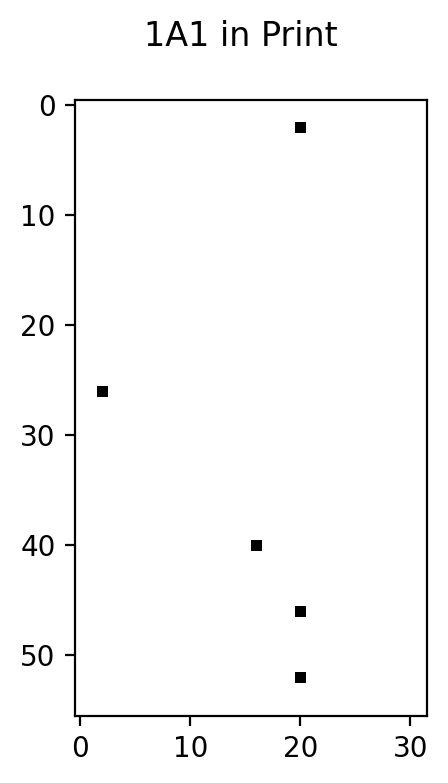

In [7]:
arrayprint.plot_mutant_position(print_array, "1A1", n_blocks)
plt.show()

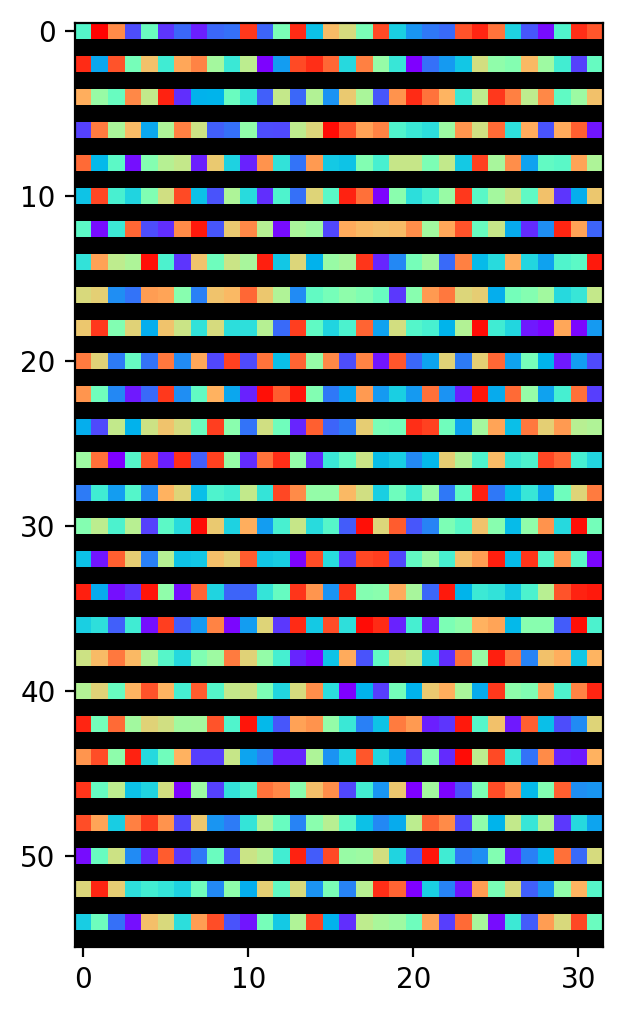

In [8]:
arrayprint.plot_array_heatmap(print_array, empty_buf_well="1P24")
plt.show()

# Save `.fld` file body in `.txt` output

Last, export this array to a fld file text output

In [11]:
arrayprint.write_fld(project, print_array, device=device)

# Read the `.fld` file back in

In [10]:
fld = arrayprint.load_fld(sorted(glob.glob(f"{project}*.fld"))[-1])
fld

array_loc                                          well  \
0 0          1/1                                           1M2   
  1          1/2  1P24,1A24,1C24,1E24,1G24,1I24,1K24,1M24,1O24   
  2          1/3                                           1C2   
  3          1/4                                          1P24   
  4          1/5                                          1I16   
...          ...                                           ...   
  1787     32/52                                          1P24   
  1788     32/53                                          1O16   
  1789     32/54                                          1P24   
  1790     32/55                                           1O6   
  1791     32/56                                          1P24   

                    spots  
0 0                     1  
  1     1,1,1,1,1,1,1,1,1  
  2                     1  
  3                     1  
  4                     1  
...                   ...  
  1787                  1  
  1788                  1  
  1789                  1  
  1790                  1  
  1791                  1  

[1792 rows x 3 columns]

In [11]:
arrayprint.get_pinlist(fld, print_plate)

Indices MutantID
x  y                    
1  1     (1, 1)     34-7
   2     (1, 2)    BLANK
   3     (1, 3)     34-2
   4     (1, 4)    BLANK
   5     (1, 5)     41-5
...         ...      ...
32 52  (32, 52)    BLANK
   53  (32, 53)     41-8
   54  (32, 54)    BLANK
   55  (32, 55)     36-8
   56  (32, 56)    BLANK

[1792 rows x 2 columns]